<a href="https://colab.research.google.com/github/Ami14123/business-analytics-project/blob/main/Data_mining_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import pandas as pd #pandas library for data manipulation and analysis
import numpy as np #NumPy library, which supports large, multi-dimensional arrays and matrices
import matplotlib.pyplot as plt #Matplotlib library, for visualizations like plots and charts
import seaborn as sns #Seaborn library, a statistical data visualization library based on Matplotlib, which provides a high-level interface for drawing attractive and informative statistical graphics
import tensorflow as tf #TensorFlow library, an open-source machine learning framework
import tensorflow_text as tft #TensorFlow Text, an extension library for handling text preprocessing and tokenization tasks in TensorFlow
import re #Regular Expressions (regex) library, which is used for string searching and manipulation
import warnings #warnings module, which handles warning messages in the code
warnings.filterwarnings('ignore') #suppresses the warning messages to make the output clear


In [ ]:
df = pd.read_csv('Restaurant reviews.csv')
df.head() #returns the first 5rows of the DataFrame df for understanding its structure



,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,7514
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,2447.0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,NaN
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,NaN
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,NaN
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,NaN


In [ ]:
df.info() #provides info of no.of rows and columns, datatypes, column names, memory usage...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Restaurant  10000 non-null  object 
 1   Reviewer    9962 non-null   object 
 2   Review      9955 non-null   object 
 3   Rating      9962 non-null   object 
 4   Metadata    9962 non-null   object 
 5   Time        9962 non-null   object 
 6   Pictures    10000 non-null  int64  
 7   7514        1 non-null      float64
dtypes: float64(1), int64(1), object(6)
memory usage: 625.1+ KB


In [ ]:
df['Rating'].value_counts() # selects the Rating and counts the no.of occurrences


,count
Rating,
5,3832
4,2373
1,1735
3,1193
2,684
4.5,69
3.5,47
2.5,19
1.5,9


In [ ]:
df[df['Rating']=='Like'].index #This filters the DataFrame, returning only the rows where the Rating is 'Like'


Index([7601], dtype='int64')

In [ ]:
df.drop(index=df[df['Rating']=='Like'].index,inplace=True) #where the Rating column has the value 'Like' will be removed
df['Rating'] = df['Rating'].apply(float) #converts the each value in the Rating to a floating-point number


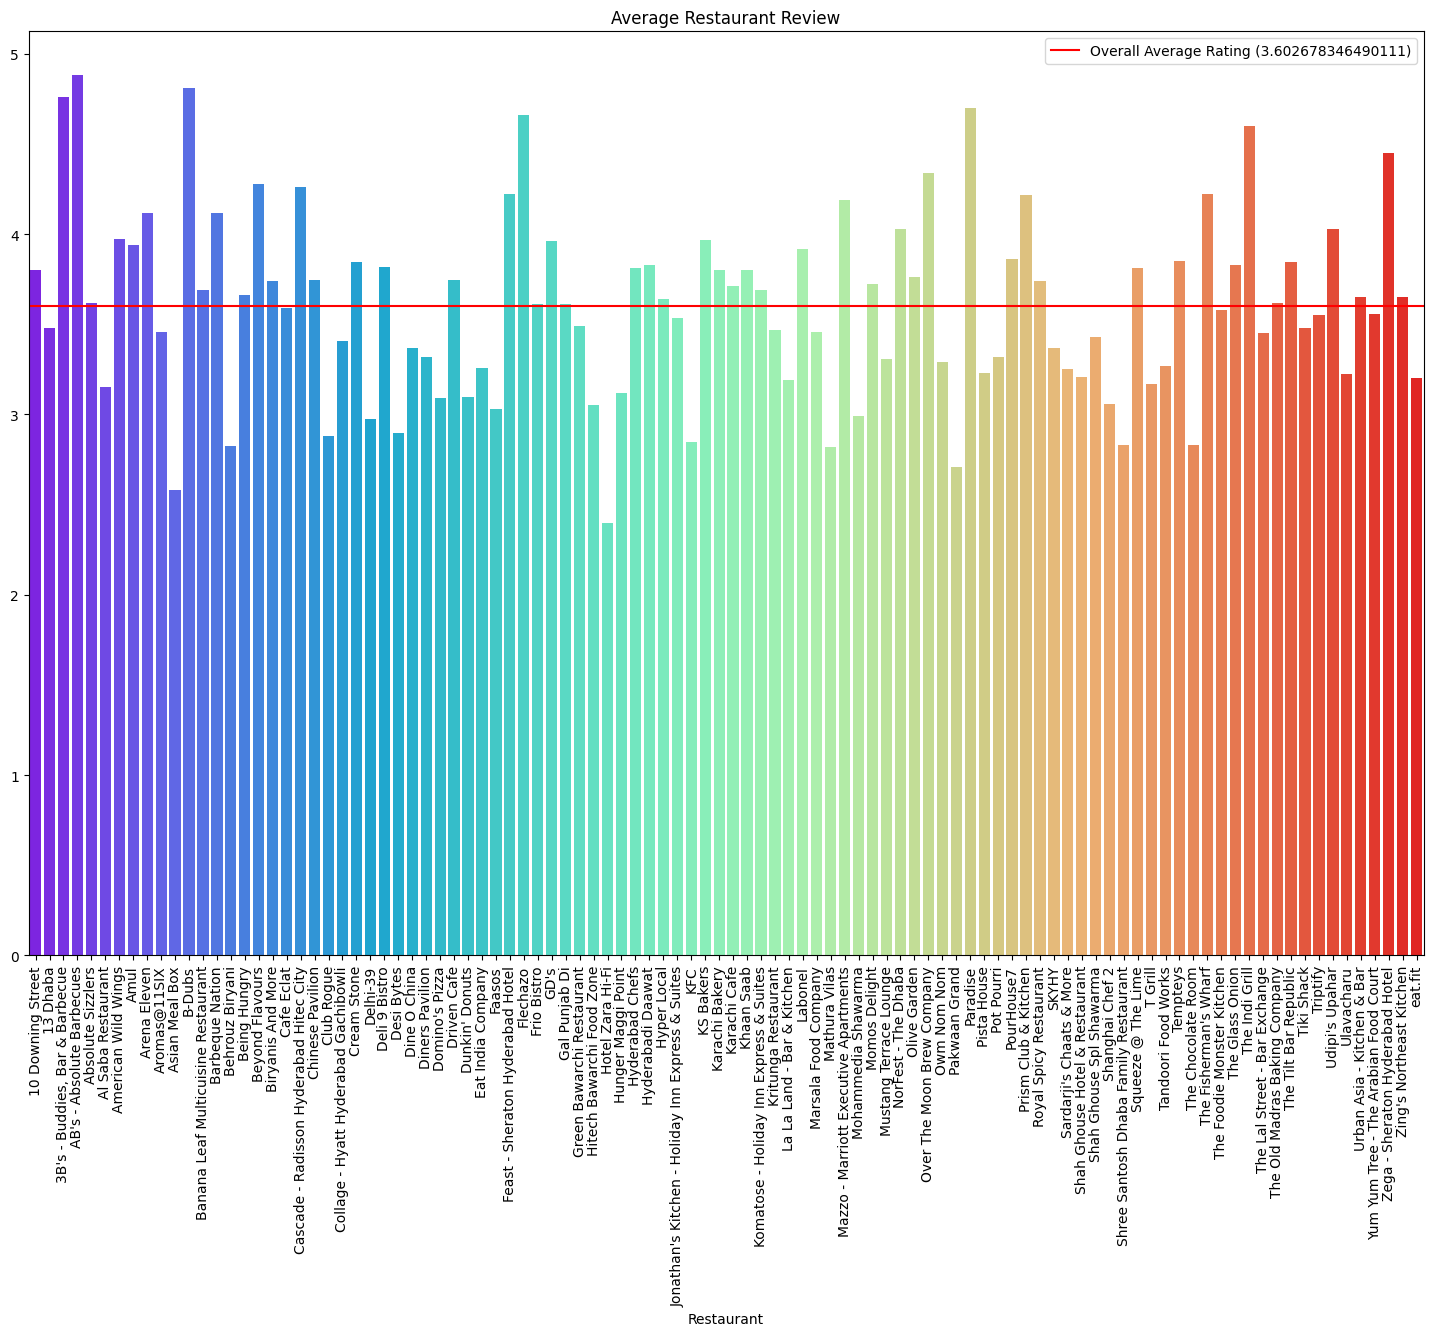

In [ ]:
# calculating the average rating for each restaurant
avg_rating = df.groupby('Restaurant')['Rating'].mean()
sns.barplot(x=avg_rating.index,y=avg_rating.values,palette='rainbow')
plt.axhline(np.mean(avg_rating.values),color='red',label=f'Overall Average Rating ({np.mean(avg_rating.values)})')
plt.xticks(rotation=90)
plt.legend()
plt.title('Average Restaurant Review')
plt.show()

In [ ]:
data = df[['Restaurant','Reviewer','Review','Rating']] #displays only these columns
data.head()

,Restaurant,Reviewer,Review,Rating
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5.0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5.0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5.0


In [ ]:
import re

def preprocess_for_lr(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)  # keep only letters
    text = re.sub(r'\s+', ' ', text)       # remove extra spaces
    return text.strip()


In [ ]:
df['clean_review'] = df['Review'].apply(preprocess_for_lr)
# sentiment label: 0 = positive, 1 = negative
df['Target'] = df['Rating'].apply(lambda x: 0 if x > 3 else 1)



## save the dataset

In [ ]:
processed_df = df[['Restaurant', 'Reviewer', 'Review', 'Rating', 'clean_review', 'Target']].copy()

processed_df.to_csv('restaurant_reviews_processed.csv', index=False, encoding='utf-8')

print("Saved processed dataset: restaurant_reviews_processed.csv")


Saved processed dataset: restaurant_reviews_processed.csv


# Model Building

## Logistic regression model

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
X = processed_df['clean_review']
y = processed_df['Target']
print(X.shape)
print(y.shape)
# Split into training+ testing:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


(9999,)
(9999,)


In [ ]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
# Train Logistic Regression:
log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train_tfidf, y_train)


LogisticRegression(max_iter=200)

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      1264
           1       0.90      0.81      0.85       736

    accuracy                           0.90      2000
   macro avg       0.90      0.88      0.89      2000
weighted avg       0.90      0.90      0.90      2000



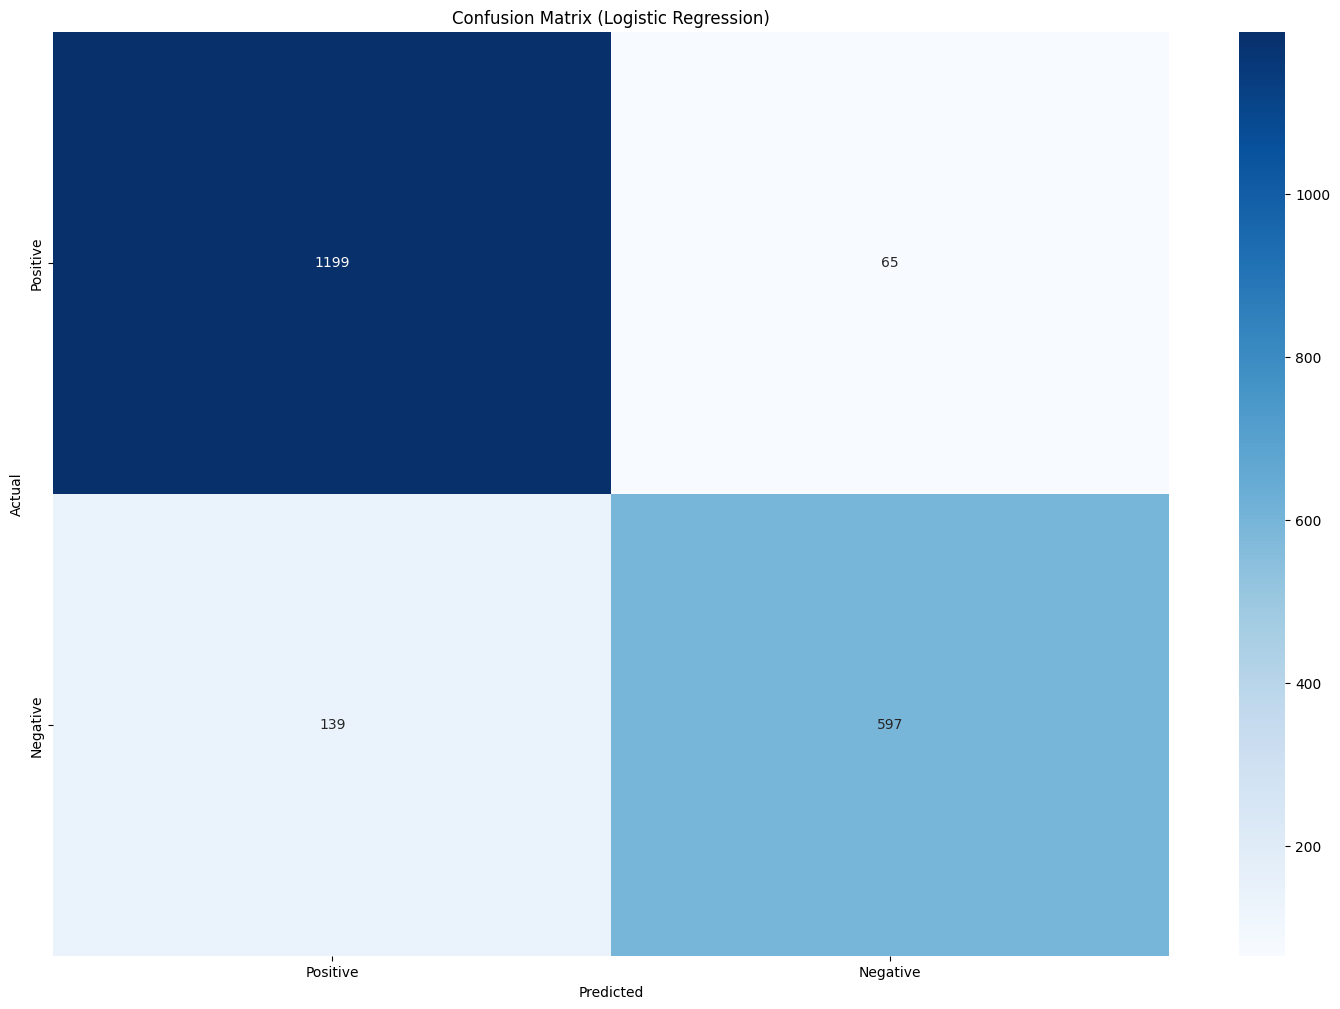

In [ ]:
y_pred = log_model.predict(X_test_tfidf)

print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Positive', 'Negative'],
            yticklabels=['Positive', 'Negative'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Logistic Regression)')
plt.show()


## train Bayesian Network Classification model:

In [ ]:
!pip install bnlearn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.4/190.4 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.7/117.7 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 6.0 MB/s eta 0:00:00
  Created wheel for semopy: filename=semopy-2.3.11-py3-none-any.whl size=1659682 sha256=7df4a667e9f7215b6750332eec54b92846168a8c1bc1e4d6c47049cb4ee73646
  Stored in directory: /root/.cache/pip/wheels/c6/24/8b/be911b059a61f490f38425eb19bf2fed470a5ead97228e8255
Successfully built semopy


In [ ]:
import bnlearn as bn


###Prepare a dataset for Bayesian model

Bayesian Networks need categorical variables, so we convert text sentiment features into:

target (positive / negative)

rating category

restaurant

review length category

In [ ]:
# sentiment label as string
processed_df['Sentiment'] = processed_df['Target'].map({0: "positive", 1: "negative"})

# bucket rating 1–5 into 3 categories
def bucket_rating(x):
    if x >= 4:
        return "High"
    elif x <= 2:
        return "Low"
    else:
        return "Medium"

processed_df['Rating_cat'] = processed_df['Rating'].apply(bucket_rating)

# review length category
processed_df['Review_len'] = processed_df['clean_review'].apply(lambda x: len(x.split()))
processed_df['Review_len_cat'] = pd.cut(
    processed_df['Review_len'],
    bins=[0, 10, 20, 50, 200],
    labels=["short", "medium", "long", "very_long"]
)
bn_data = processed_df[['Sentiment', 'Rating_cat', 'Restaurant', 'Review_len_cat']]
bn_data.head()



,Sentiment,Rating_cat,Restaurant,Review_len_cat
0,positive,High,Beyond Flavours,long
1,positive,High,Beyond Flavours,long
2,positive,High,Beyond Flavours,long
3,positive,High,Beyond Flavours,long
4,positive,High,Beyond Flavours,long


[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Compute structure scores for model comparison (higher is better).
[bnlearn] >Set node properties.
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


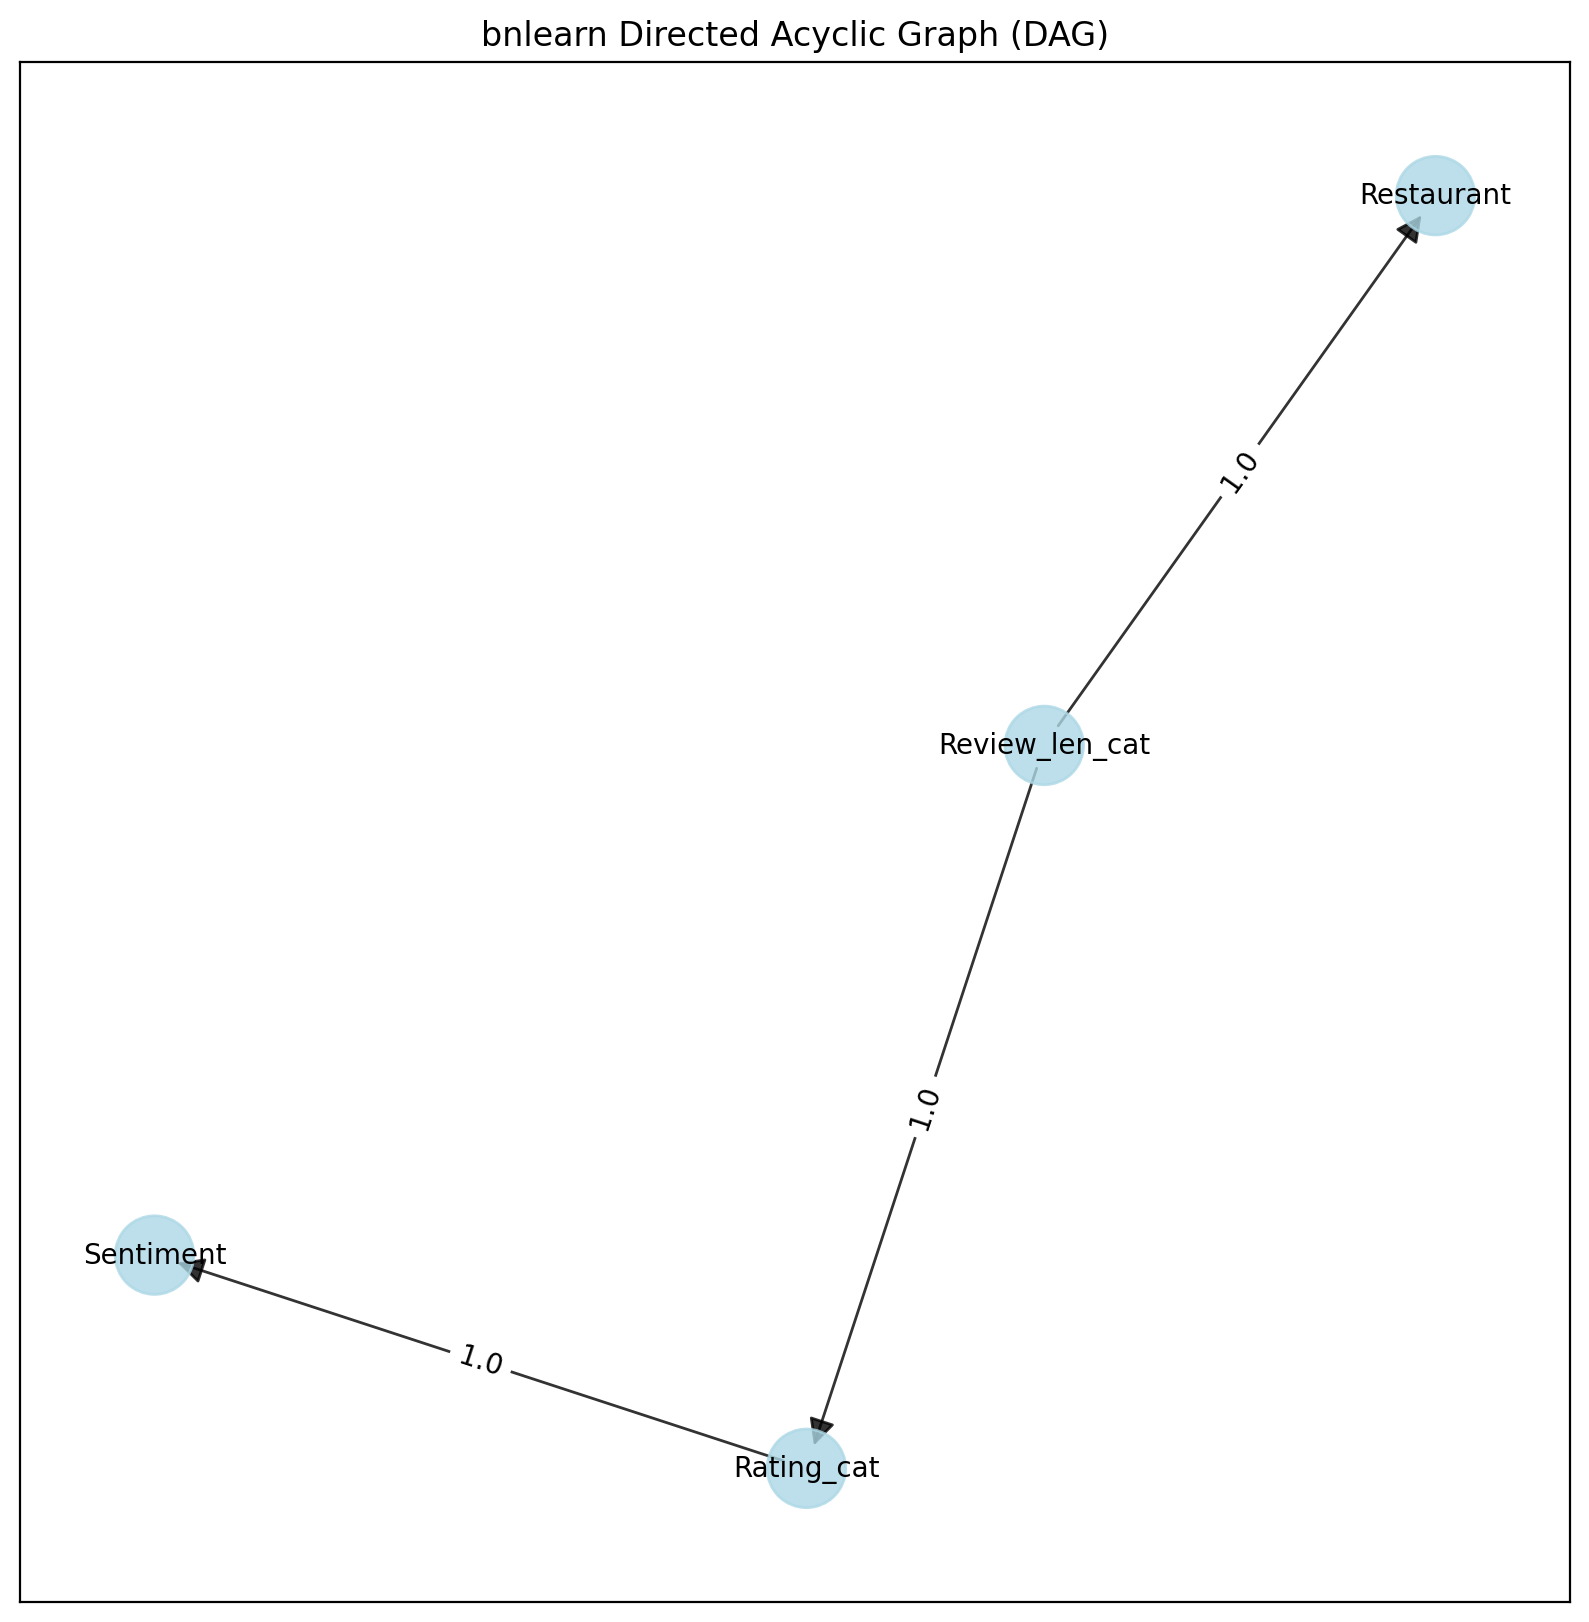

{'fig': <Figure size 2000x2000 with 1 Axes>,
 'ax': <Figure size 2000x2000 with 1 Axes>,
 'pos': {'Rating_cat': array([-0.07615631, -0.67638872]),
  'Sentiment': array([-1.        , -0.41519785]),
  'Review_len_cat': array([0.26082498, 0.20909743]),
  'Restaurant': array([0.81533133, 0.88248915])},
 'G': <networkx.classes.digraph.DiGraph at 0x7e99a8c5a6c0>,
 'node_properties': {'Sentiment': {'node_color': '#ADD8E6', 'node_size': 800},
  'Rating_cat': {'node_color': '#ADD8E6', 'node_size': 800},
  'Restaurant': {'node_color': '#ADD8E6', 'node_size': 800},
  'Review_len_cat': {'node_color': '#ADD8E6', 'node_size': 800}},
 'edge_properties': {('Rating_cat', 'Sentiment'): {'color': '#000000',
   'weight': np.float64(1.0),
   'pvalue': 1,
   'value': np.float64(1.0)},
  ('Review_len_cat', 'Rating_cat'): {'color': '#000000',
   'weight': np.float64(1.0),
   'pvalue': 1,
   'value': np.float64(1.0)},
  ('Review_len_cat', 'Restaurant'): {'color': '#000000',
   'weight': np.float64(1.0),
   'pv

In [ ]:
model = bn.structure_learning.fit(bn_data, methodtype='hc')  # hc = hillclimb
bn.plot(model)


[bnlearn] >Parameter learning> Computing parameters using [bayes]
[bnlearn] >Converting [<class 'pgmpy.base.DAG.DAG'>] to BayesianNetwork model.
[bnlearn] >Converting adjmat to BayesianNetwork.
[bnlearn] >CPD of Rating_cat:
+--------------------+-----+---------------------------+
| Review_len_cat     | ... | Review_len_cat(very_long) |
+--------------------+-----+---------------------------+
| Rating_cat(High)   | ... | 0.5593767390094602        |
+--------------------+-----+---------------------------+
| Rating_cat(Low)    | ... | 0.2558708959376739        |
+--------------------+-----+---------------------------+
| Rating_cat(Medium) | ... | 0.1847523650528659        |
+--------------------+-----+---------------------------+
[bnlearn] >CPD of Sentiment:
+---------------------+-----+--------------------+
| Rating_cat          | ... | Rating_cat(Medium) |
+---------------------+-----+--------------------+
| Sentiment(negative) | ... | 0.8689429564506236 |
+---------------------+-----+-

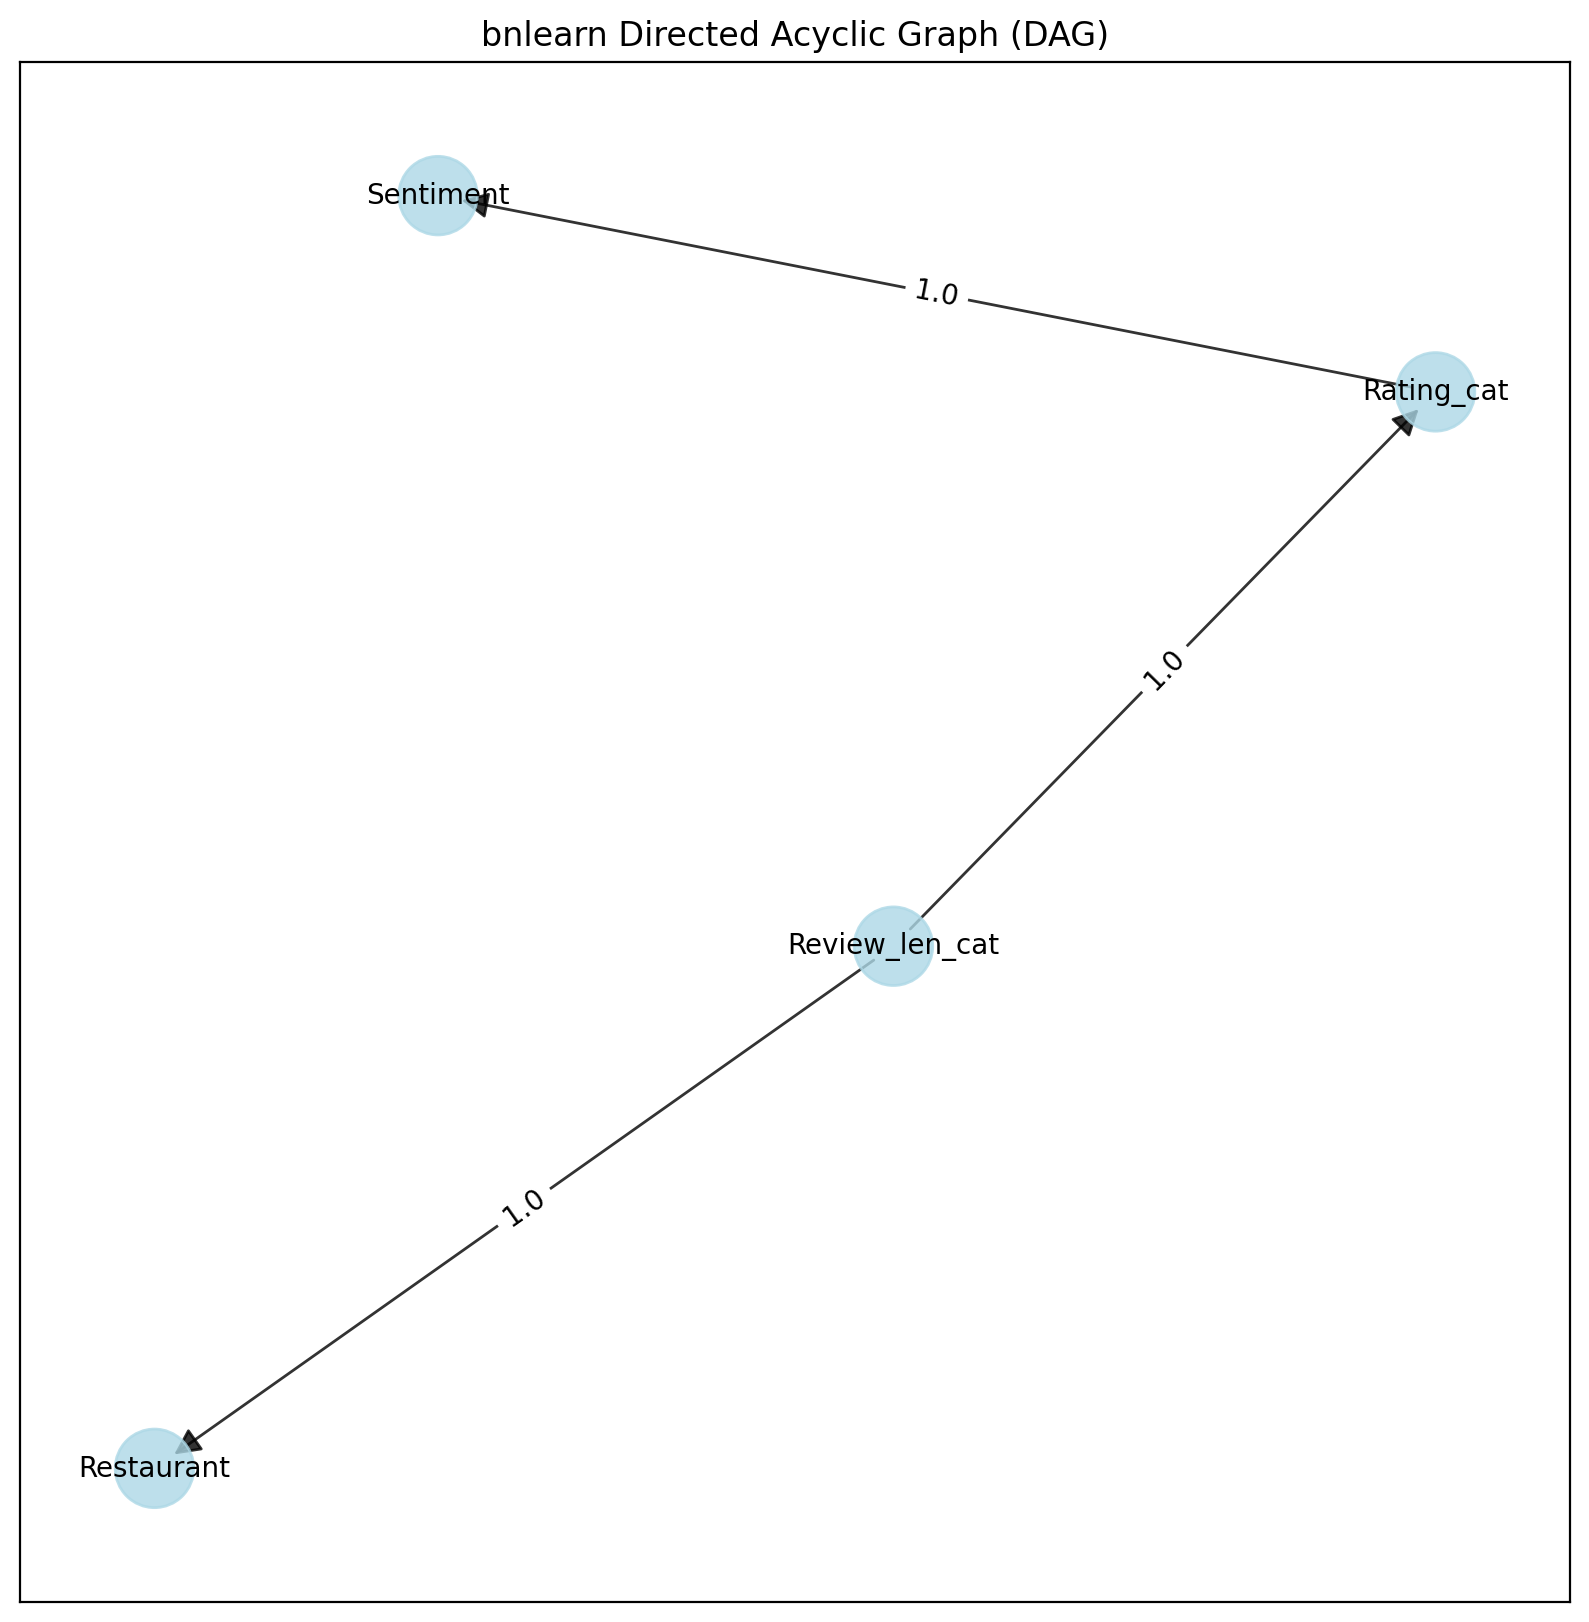

{'fig': <Figure size 2000x2000 with 1 Axes>,
 'ax': <Figure size 2000x2000 with 1 Axes>,
 'pos': {'Rating_cat': array([0.25329319, 0.49960743]),
  'Sentiment': array([-0.10502075,  0.77299344]),
  'Review_len_cat': array([ 0.05858331, -0.27260088]),
  'Restaurant': array([-0.20685575, -1.        ])},
 'G': <networkx.classes.digraph.DiGraph at 0x7e99a811c8f0>,
 'node_properties': {'Sentiment': {'node_color': '#ADD8E6', 'node_size': 800},
  'Rating_cat': {'node_color': '#ADD8E6', 'node_size': 800},
  'Restaurant': {'node_color': '#ADD8E6', 'node_size': 800},
  'Review_len_cat': {'node_color': '#ADD8E6', 'node_size': 800}},
 'edge_properties': {('Rating_cat', 'Sentiment'): {'color': '#000000',
   'weight': np.float64(1.0),
   'pvalue': 1,
   'value': np.float64(1.0)},
  ('Review_len_cat', 'Rating_cat'): {'color': '#000000',
   'weight': np.float64(1.0),
   'pvalue': 1,
   'value': np.float64(1.0)},
  ('Review_len_cat', 'Restaurant'): {'color': '#000000',
   'weight': np.float64(1.0),
   '

In [ ]:
bn_model = bn.parameter_learning.fit(model, bn_data)
bn.plot(bn_model)


In [ ]:
query = bn.inference.fit(
    bn_model,
    variables=['Sentiment'],
    evidence={'Rating_cat': 'High', 'Review_len_cat': 'short'}
)
query


[bnlearn] >Variable Elimination.
+----+-------------+-----------+
|    | Sentiment   |         p |
+====+=============+===========+
|  0 | negative    | 0.0252245 |
+----+-------------+-----------+
|  1 | positive    | 0.974776  |
+----+-------------+-----------+

Summary for variables: ['Sentiment']
Given evidence: Rating_cat=High, Review_len_cat=short

Sentiment outcomes:
- Sentiment: negative (2.5%)
- Sentiment: positive (97.5%)


<DiscreteFactor representing phi(Sentiment:2) at 0x7e99a8025c70>

In [ ]:
def bn_predict_sentiment(model, rating_cat, review_len_cat):
    result = bn.inference.fit(
        model,
        variables=['Sentiment'],
        evidence={'Rating_cat': rating_cat, 'Review_len_cat': review_len_cat}
    )

    # Extract probability for 'positive'
    prob_pos = result.df[result.df['Sentiment'] == 'positive']['p'].values[0]
    prob_neg = result.df[result.df['Sentiment'] == 'negative']['p'].values[0]

    return 'positive' if prob_pos >= 0.5 else 'negative'


## Build SVM model:


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=7000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)


LinearSVC()

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1264
           1       0.86      0.83      0.85       736

    accuracy                           0.89      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.89      0.89      0.89      2000



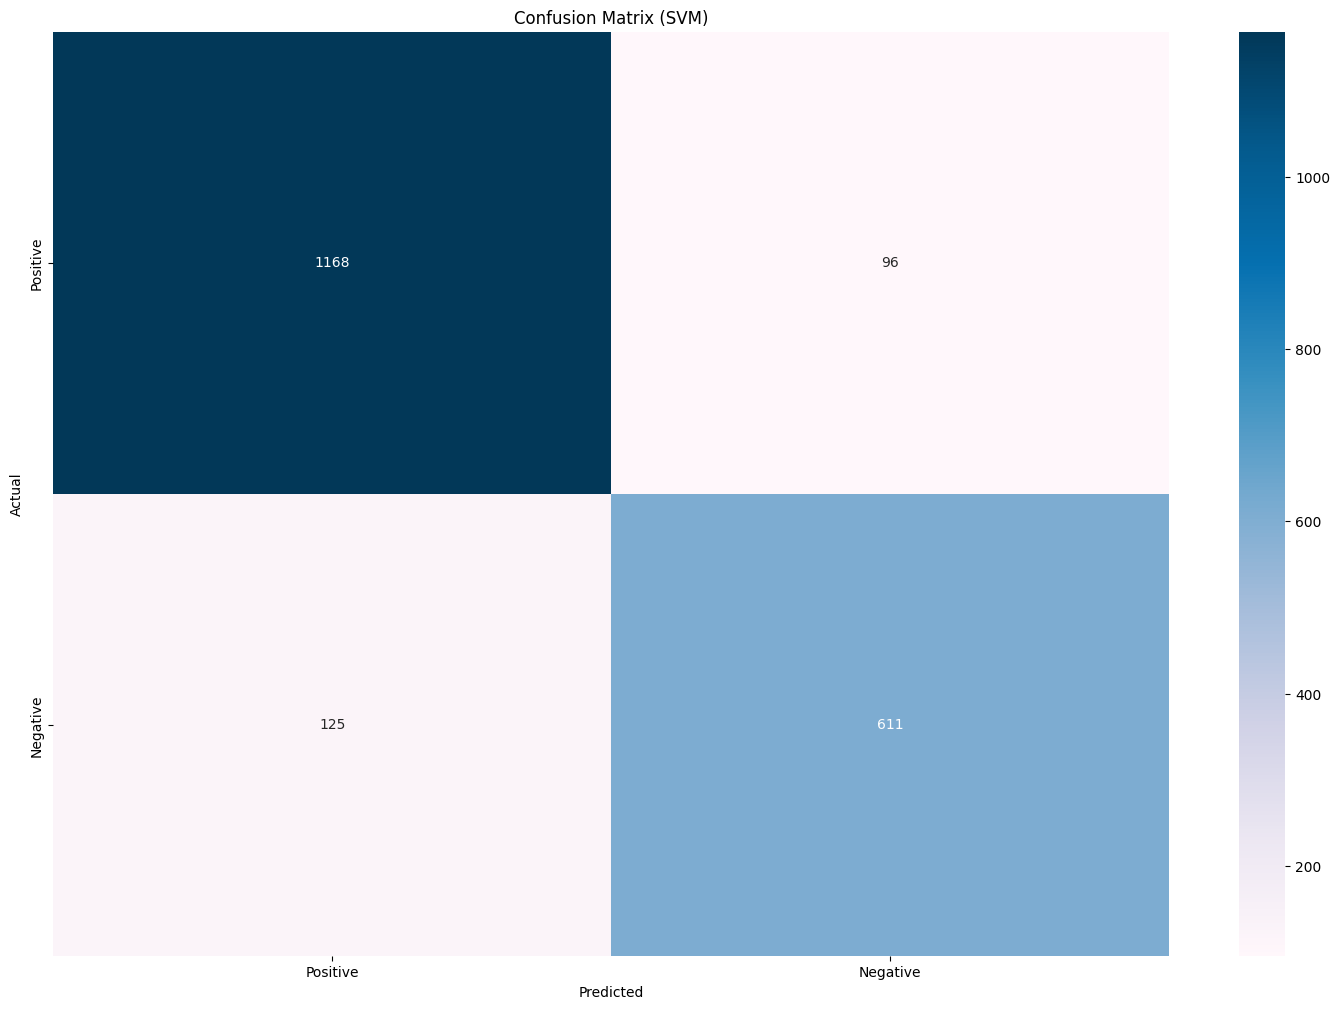

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = svm_model.predict(X_test_tfidf)

print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='PuBu',
            xticklabels=['Positive', 'Negative'],
            yticklabels=['Positive', 'Negative'])
plt.title('Confusion Matrix (SVM)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
def predict_svm(review):
    review_clean = tfidf.transform([review])
    pred = svm_model.predict(review_clean)[0]
    return "Positive" if pred == 0 else "Negative"

predict_svm("The food was amazing but service was slow")



'Positive'

In [ ]:
import joblib

joblib.dump(svm_model, "svm_sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("SVM model + TF-IDF saved!")


SVM model + TF-IDF saved!


## Build random forest model:


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=7000)  # unigram default
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,        # number of trees
    max_depth=None,         # let tree grow naturally
    n_jobs=-1,              # use all CPU cores
    random_state=42
)

rf_model.fit(X_train_tfidf, y_train)


RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1264
           1       0.90      0.77      0.83       736

    accuracy                           0.88      2000
   macro avg       0.89      0.86      0.87      2000
weighted avg       0.89      0.88      0.88      2000



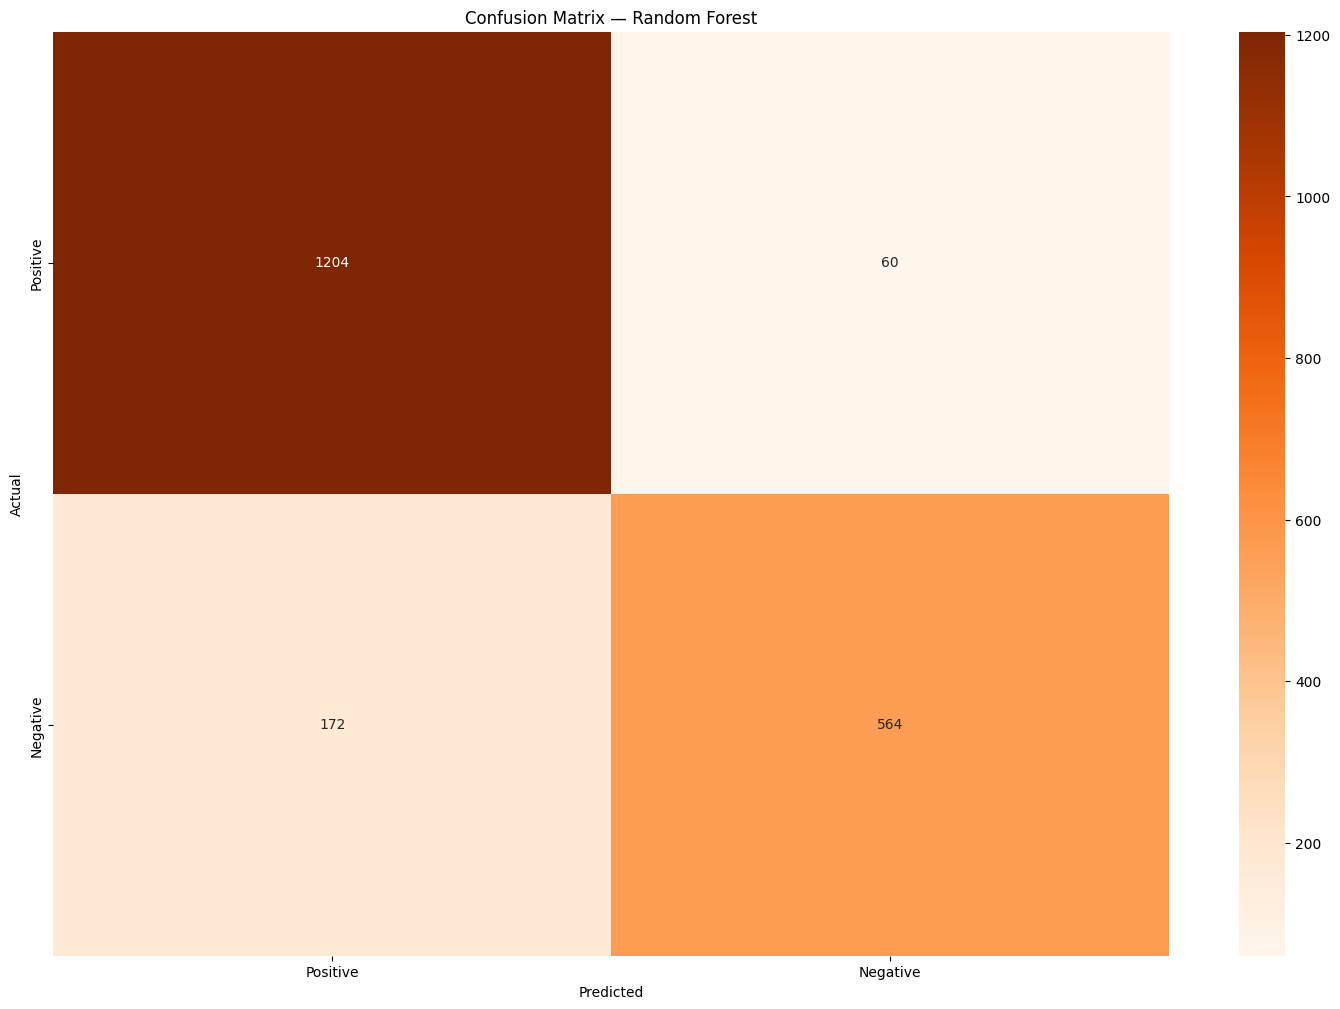

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = rf_model.predict(X_test_tfidf)

print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Oranges',
    xticklabels=['Positive', 'Negative'],
    yticklabels=['Positive', 'Negative']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Random Forest")
plt.show()


In [ ]:
def predict_rf(review):
    vec = tfidf.transform([review])
    pred = rf_model.predict(vec)[0]
    return "Positive" if pred == 0 else "Negative"
predict_rf("The food was delicious but the service was slow")


'Positive'

In [ ]:
import joblib

joblib.dump(rf_model, "random_forest_sentiment.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Random Forest + TF-IDF saved!")


Random Forest + TF-IDF saved!
